Importing the libraries

In [10]:
# Data manipulation and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, RocCurveDisplay
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.model_selection import cross_val_score

from sklearn.metrics import precision_recall_curve, confusion_matrix
from sklearn.ensemble import RandomForestClassifier


### Gradient Boosting 
- XGBoost é um modelo de Gradient Boosting, técnica incluída dentro de classificadores Ensemble;
- Ensemble: métodos que utilizam uma combinação de resultados de preditores fracos (modelos q quando usados individualmente possuem baixa acurácia) pra produzir um melhor modelo preditivo;
- Para os modelos fracos são geralmente utilizados árvores de decisão mas não existe restrição;
- Diferente do Bagging que os preditores fracos são treinados de forma individual e paralela, e no final são combinados seguindo uma média. 
- No caso dos boosting, eles são sequenciais e cada modelo depende do resultado dos anteriores;|
- Cada etapa tem como objetivo minimizar o erro do anterior por meio da função de perda

-

In [9]:
import xgboost as xgb
from xgboost import XGBClassifier

In [7]:
df = pd.read_csv('../Data/input/creditcard.csv') 

X = df.drop(columns=["Class"])
y = df["Class"]

# Divisão teste e treino
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


Hyperparameter tuning
- XGBoost permite alteraçoes de vários hiperparâmetros como learning rate, altura máxima, quantidade máxima de folhas nas árvores, número de árvoores (estimadores), etc

In [11]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [12]:
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:,1]


In [14]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.92      0.79      0.85        98

    accuracy                           1.00     56962
   macro avg       0.96      0.89      0.92     56962
weighted avg       1.00      1.00      1.00     56962



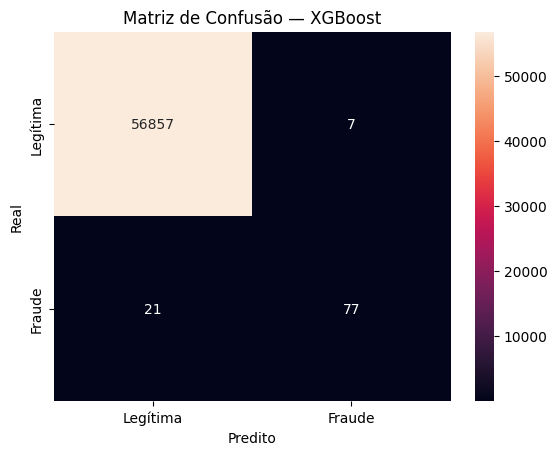

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Legítima','Fraude'],
    yticklabels=['Legítima','Fraude']
)

plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão — XGBoost")
plt.show()